1. Loading data and inspecting it

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("games.csv")
df.head()


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


2. Feature Engineering

    A. Rating Difference

In [6]:
df["rating_diff"] = df["white_rating"] - df["black_rating"]

In [7]:
print(df["rating_diff"])

0        309
1         61
2         -4
3        -15
4         54
        ... 
20053    471
20054     37
20055    -67
20056    133
20057   -104
Name: rating_diff, Length: 20058, dtype: int64


    B. Number of Moves

In [8]:
df["num_moves"] = df["moves"].apply(lambda x: len(x.split()))
print(df["num_moves"])

0         13
1         16
2         61
3         61
4         95
        ... 
20053     24
20054     82
20055     35
20056    109
20057     78
Name: num_moves, Length: 20058, dtype: int64


In [9]:
df["simple_opening"] = df["opening_name"].apply(lambda x: x.split(":")[0])
print(df["simple_opening"])
df["variation"] = df["opening_name"].apply(lambda y: y.split(":")[1] if ":" in y else "Main line")
print(df["variation"])

0               Slav Defense
1        Nimzowitsch Defense
2           King's Pawn Game
3          Queen's Pawn Game
4           Philidor Defense
                ...         
20053          Dutch Defense
20054           Queen's Pawn
20055      Queen's Pawn Game
20056           Pirc Defense
20057      Queen's Pawn Game
Name: simple_opening, Length: 20058, dtype: object
0          Exchange Variation
1           Kennedy Variation
2         Leonardis Variation
3         Zukertort Variation
4                   Main line
                 ...         
20053               Main line
20054               Main line
20055            Mason Attack
20056               Main line
20057            Mason Attack
Name: variation, Length: 20058, dtype: object


3. Exploratory Data Analysis

In [10]:
df.groupby("simple_opening")["rating_diff"].mean()

simple_opening
Alekhine Defense              39.989362
Alekhine Defense #2           73.000000
Alekhine Defense #3         -143.000000
Amar Opening                -227.642857
Amazon Attack                 48.000000
                                ...    
Wade Defense                  30.000000
Ware Defense                   8.916667
Ware Opening                 -47.458333
Yusupov-Rubinstein System    -71.000000
Zukertort Opening             35.872024
Name: rating_diff, Length: 227, dtype: float64

In [11]:
df.groupby("victory_status")["rating_diff"].mean()

victory_status
draw         16.912804
mate          5.913992
outoftime     2.883333
resign        8.870279
Name: rating_diff, dtype: float64

higher rating diff for draws might indicate people generally opt for the safer result when rating diff is higher, as the higher rated players may not want to lose rating and lower rated players are happy to even draw..?

4. Prepare Data for ML

In [12]:
x = df[["rating_diff","num_moves"]]
y = df["winner"]

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [17]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy_score(y_test,y_pred)

0.7006480558325024

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.71      0.71      1887
           1       0.23      0.13      0.17       193
           2       0.71      0.75      0.73      1932

    accuracy                           0.70      4012
   macro avg       0.55      0.53      0.54      4012
weighted avg       0.69      0.70      0.69      4012



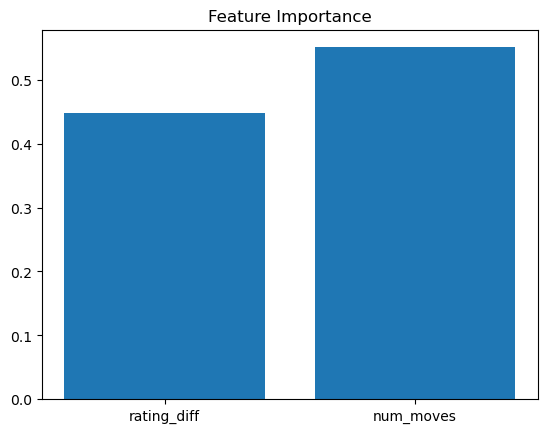

In [22]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = x.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()


In [ ]:
def rating_category(x):
    if x < 1200:
        return "beginner"
    elif x < 1800:
        return "intermediate"
    else:
        return "advanced"

df["white_level"] = df["white_rating"].apply(rating_category)
